# Notebook Final : Skip-Gram + PCA + KMeans (100% autonome)
Ce notebook contient tout : entraînement Skip-Gram, ACP 2D, clustering KMeans, visualisation.

In [1]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import numpy as np
import re

## 1. Corpus + Préparation

In [2]:
corpus = '''Le Maroc est un pays situé en Afrique du nord. Sa capitale est Rabat. Marrakech est une ville connue pour sa médina animée. Casablanca est le centre économique. L'intelligence artificielle et l'apprentissage automatique permettent d'apprendre à partir des données.'''
corpus = re.sub(r"[^a-zA-Zàâçéèêëîïôûùüÿñæœ' ]+"," ", corpus)
words = corpus.lower().split()
vocab = sorted(set(words))
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
vocab_size = len(vocab)
vocab_size, words[:10]

(34,
 ['le', 'maroc', 'est', 'un', 'pays', 'situé', 'en', 'afrique', 'du', 'nord'])

## 2. Paires Skip-Gram

In [3]:
def generate_pairs(words, window=2):
    pairs=[]
    for i,w in enumerate(words):
        for j in range(max(0,i-window), min(len(words),i+window+1)):
            if j!=i: pairs.append((w,words[j]))
    return pairs
pairs = generate_pairs(words, 2)
len(pairs)

150

In [4]:
inputs = torch.tensor([word2idx[c] for c,_ in pairs])
targets = torch.tensor([word2idx[t] for _,t in pairs])
inputs[:5], targets[:5]

(tensor([17, 17, 18, 18, 18]), tensor([18, 13, 17, 13, 29]))

## 3. Dataset & DataLoader

In [5]:
class SGDataset(Dataset):
    def __init__(self,x,y): self.x=x; self.y=y
    def __len__(self): return len(self.x)
    def __getitem__(self,i): return self.x[i], self.y[i]
dl = DataLoader(SGDataset(inputs,targets), batch_size=32, shuffle=True)

## 4. Modèle Skip-Gram

In [6]:
class SkipGram(nn.Module):
    def __init__(self,vocab,emb):
        super().__init__()
        self.e=nn.Embedding(vocab,emb)
        self.l=nn.Linear(emb,vocab)
    def forward(self,c): return self.l(self.e(c))
model = SkipGram(vocab_size,50)
opt = optim.Adam(model.parameters(), lr=0.002)
lossf = nn.CrossEntropyLoss()

## 5. Entraînement

In [7]:
for ep in range(5):
    tot=0
    for c,t in dl:
        opt.zero_grad(); out=model(c); loss=lossf(out,t); loss.backward(); opt.step(); tot+=loss.item()
    print('Epoch',ep,'Loss',tot)

Epoch 0 Loss 18.769493103027344
Epoch 1 Loss 18.107436895370483
Epoch 2 Loss 17.649228811264038
Epoch 3 Loss 17.124502897262573
Epoch 4 Loss 16.65214228630066


## 6. PCA 2D

In [8]:
embedding_matrix = model.e.weight.detach().numpy()
pca = PCA(n_components=2)
reduced = pca.fit_transform(embedding_matrix)
reduced[:5]

array([[-1.2653857 , -3.2003505 ],
       [-0.70548826,  0.66619426],
       [-0.9776943 ,  0.857288  ],
       [-2.0840168 ,  1.5372678 ],
       [ 4.8989143 , -0.9145587 ]], dtype=float32)

## 7. KMeans (distance cosinus via normalisation)

In [9]:
norm = normalize(embedding_matrix, norm='l2')
kmeans = KMeans(n_clusters=4, n_init='auto').fit(norm)
clusters = kmeans.labels_
clusters[:10]

array([0, 0, 1, 0, 0, 1, 1, 1, 3, 3], dtype=int32)

## 8. Visualisation finale

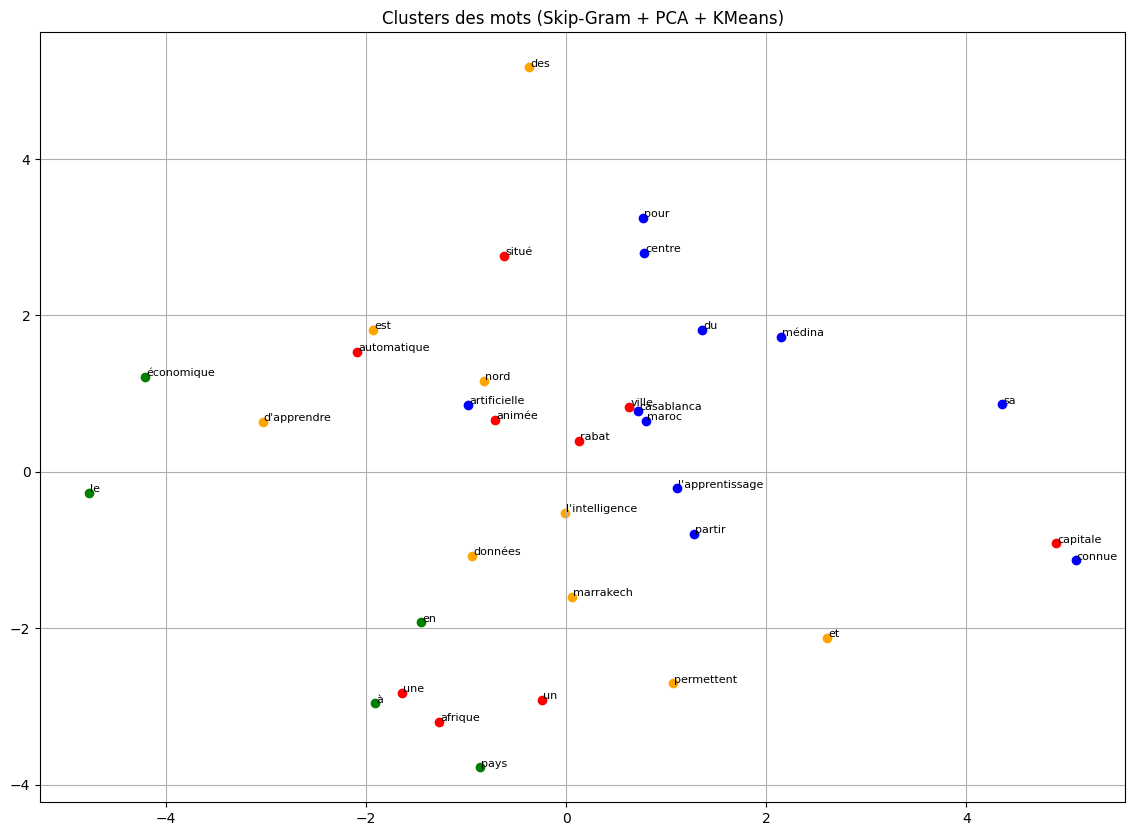

In [10]:
plt.figure(figsize=(14,10))
colors=['red','blue','green','orange']
for i,w in enumerate(vocab):
    x,y=reduced[i]; c=clusters[i]
    plt.scatter(x,y,color=colors[c]); plt.text(x+0.01,y+0.01,w,fontsize=8)
plt.title('Clusters des mots (Skip-Gram + PCA + KMeans)'); plt.grid(True); plt.show()